# Malaria Cell Detection using Convolutional Neural Network (CNN)

This notebook builds a **binary image classifier** to detect whether a cell image
is **Parasitized** (infected with malaria) or **Uninfected**.

## Pipeline Overview
1. Install & import required libraries
2. Explore the dataset (sample images, class distribution)
3. Preprocess data using `ImageDataGenerator`
4. Build a CNN model
5. Train the model with early stopping
6. Evaluate performance with curves, ROC, and confusion matrix
7. Visualize model attention using Grad-CAM++


In [1]:
import os
import torch

# CPU: Use ALL cores
num_cores = os.cpu_count()
torch.set_num_threads(num_cores)
torch.set_num_interop_threads(num_cores)

# GPU: Enable full usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Enable fastest GPU settings
torch.backends.cudnn.benchmark = True   # optimize for speed
torch.backends.cudnn.enabled = True

# Mixed Precision (FASTER + uses GPU fully)
from torch.cuda.amp import GradScaler
scaler = GradScaler()

# Optional: Multi-GPU support
def prepare_model(model):
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs")
        model = torch.nn.DataParallel(model)
    return model.to(device)

C:\Users\FRIDAY\AppData\Local\Temp\ipykernel_22920\1296619666.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
c:\Users\FRIDAY\anaconda3\Lib\site-packages\torch\amp\grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


## 2. Import Libraries


In [2]:
# --- Standard Library ---
import random, warnings
warnings.filterwarnings('ignore')
# --- Numerical & Data ---
import numpy as np
import pandas as pd
from tqdm import tqdm
# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
# --- Deep Learning ---
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPool2D, Dropout, Flatten, Dense, BatchNormalization)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
# --- Evaluation ---
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_score,
                             recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
# --- Grad-CAM ---
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore
# fixing the seed here so my graphs don't jump around every run
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # keeps TensorFlow from spamming the notebook
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

GPU available      : False


## 3. Define Dataset Paths

The dataset lives in `dataset/cell_images/` with two sub-folders:
- `Parasitized/` ? images of infected cells
- `Uninfected/` ? images of healthy cells


In [3]:
DATA_DIR   = 'dataset'
IMG_WIDTH  = 128
IMG_HEIGHT = 128
IMG_SIZE   = (IMG_WIDTH, IMG_HEIGHT)
BATCH_SIZE = 16
EPOCHS     = 20
VAL_SPLIT  = 0.2   # 80% train, 20% validation

## 4. Explore the Dataset

Let's check how many images are in each class and display some samples.


In [4]:
parasitized_dir = os.path.join(DATA_DIR, 'Parasitized')
uninfected_dir  = os.path.join(DATA_DIR, 'Uninfected')

valid_ext = ('.png', '.jpg', '.jpeg')  # Kaggle is mostly png, but this avoids missing jpg files

para_files  = [f for f in os.listdir(parasitized_dir) if f.lower().endswith(valid_ext)]
uninf_files = [f for f in os.listdir(uninfected_dir)  if f.lower().endswith(valid_ext)]

para_count  = len(para_files)
uninf_count = len(uninf_files)
total       = para_count + uninf_count

print(f"Parasitized images : {para_count}")
print(f"Uninfected images  : {uninf_count}")
print(f"Total images       : {total}")
print(f"Class balance      : {para_count/total*100:.1f}% vs {uninf_count/total*100:.1f}%")
# roughly balanced but compute class weights just to be safe

Parasitized images : 13779
Uninfected images  : 13779
Total images       : 27558
Class balance      : 50.0% vs 50.0%


## 4.1 Class Distribution


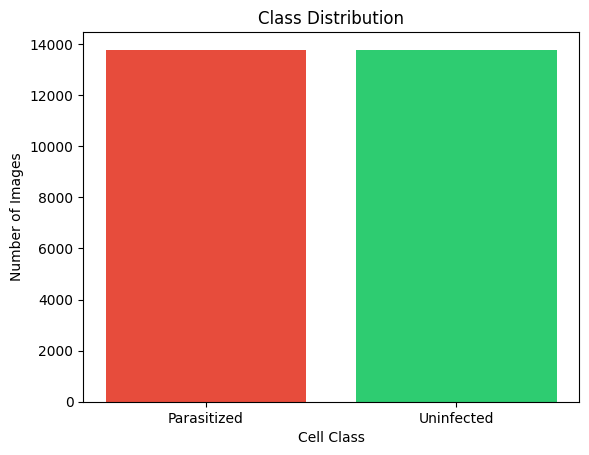

In [5]:
# keeping the simple bar chart because it tells the story
classes = ['Parasitized', 'Uninfected']
counts  = [para_count, uninf_count]
colors  = ['#e74c3c', '#2ecc71']

bars = plt.bar(classes, counts, color=colors)
plt.title('Class Distribution')
plt.xlabel('Cell Class')
plt.ylabel('Number of Images')
plt.show()

## 4.2 Sample Cell Images


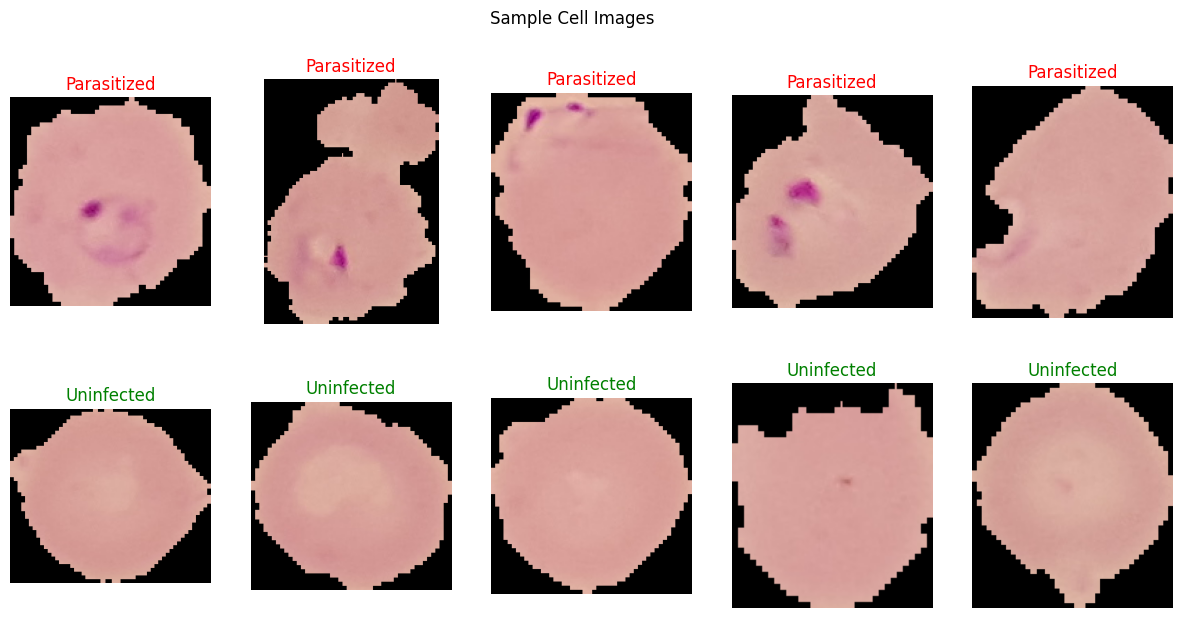

In [6]:
# using the first few examples just to check the cells look loaded properly
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for i, ax in enumerate(axes[0]):
    img_name = para_files[i]
    img = cv2.cvtColor(cv2.imread(os.path.join(parasitized_dir, img_name)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title('Parasitized', color='red')
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    img_name = uninf_files[i]
    # same view for healthy cells so the comparison is fair
    img = cv2.cvtColor(cv2.imread(os.path.join(uninfected_dir, img_name)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title('Uninfected', color='green')
    ax.axis('off')

plt.suptitle('Sample Cell Images')
plt.show()


## 5a. Compute Class Weights


In [7]:
# sklearn needs numeric labels ? 0 for Parasitized, 1 for Uninfected (alphabetical order)
labels_array = np.array([0]*para_count + [1]*uninf_count)
class_weights_vals = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)
class_weights_dict = dict(enumerate(class_weights_vals))
print(f"Class weights: {class_weights_dict}")
# values close to 1.0 = balanced; if one is much higher, the model will penalise


Class weights: {0: 1.0, 1: 1.0}


## 5b. Data Generators with Augmentation


In [8]:
# augmentation only on training data ? val/test data should NOT be augmented
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=VAL_SPLIT,
    rotation_range=15,           # cells can appear at any angle under microscope
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.05
)

val_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=VAL_SPLIT
)

train_gen = train_datagen.flow_from_directory(
    directory=DATA_DIR, target_size=IMG_SIZE,
    class_mode='binary', batch_size=BATCH_SIZE,
    subset='training', shuffle=True, seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    directory=DATA_DIR, target_size=IMG_SIZE,
    class_mode='binary', batch_size=BATCH_SIZE,
    subset='validation', shuffle=False, seed=SEED
)

print(f"\nClass indices : {train_gen.class_indices}")
print(f"Train batches : {len(train_gen)}")
print(f"Val batches   : {len(val_gen)}")


Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.

Class indices : {'Parasitized': 0, 'Uninfected': 1}
Train batches : 1378
Val batches   : 345


## 6. CNN Architecture

I chose a 3-block CNN where each block goes Conv ? BatchNorm ? MaxPool ? Dropout.
Filters double each block (16 ? 32 ? 64) so early layers catch edges/textures,
deeper layers catch more complex patterns like the malaria parasite shape.

- **BatchNormalization** ? stabilises training, lets me use a slightly higher LR
- **MaxPooling** ? cuts spatial size in half each block, reduces parameters
- **Dropout** ? prevents overfitting (the dataset isn't huge, so this matters)
- **Final sigmoid** ? gives a probability: >0.5 = Parasitized


In [9]:
# keeping the architecture exactly as planned: 16 ? 32 ? 64 ? 128
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(), MaxPool2D(pool_size=(2, 2)), Dropout(0.2),

    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(), MaxPool2D(pool_size=(2, 2)), Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(), MaxPool2D(pool_size=(2, 2)), Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(), MaxPool2D(pool_size=(2, 2)), Dropout(0.3),

    Flatten(), Dense(128, activation='relu'), Dropout(0.5),
    Dense(1, activation='sigmoid')  # one output neuron is enough for binary classification
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,481 (2.63 MB)

 Trainable params: 688,001 (2.62 MB)

 Non-trainable params: 480 (1.88 KB)

## 7. Compile the Model


In [10]:
# tracking more than accuracy because false negatives matter
model.compile(
    optimizer=Adam(learning_rate=5e-4),   # lower LR than default 1e-3 ? more stable
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)


## 8. Train the Model


In [11]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.h5', monitor='val_loss',
    save_best_only=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-7, verbose=1
)

history = model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    epochs=EPOCHS,
    validation_data=val_gen,
    validation_steps=len(val_gen),
    callbacks=[early_stop, checkpoint, reduce_lr],
    class_weight=class_weights_dict   # accounts for any slight imbalance
)

print(f"\n? Training done in {len(history.history['loss'])} epochs")
print(f"   Best val_loss    : {min(history.history['val_loss']):.4f}")
print(f"   Best val_accuracy: {max(history.history['val_accuracy']):.4f}")


Epoch 1/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.6617 - auc: 0.7144 - loss: 0.6838 - precision: 0.6640 - recall: 0.6511
Epoch 1: val_loss improved from inf to 0.43097, saving model to best_model.h5


1378/1378 ━━━━━━━━━━━━━━━━━━━━ 358s 252ms/step - accuracy: 0.6617 - auc: 0.7145 - loss: 0.6837 - precision: 0.6641 - recall: 0.6512 - val_accuracy: 0.8172 - val_auc: 0.9324 - val_loss: 0.4310 - val_precision: 0.9031 - val_recall: 0.7107 - learning_rate: 5.0000e-04
Epoch 2/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9292 - auc: 0.9637 - loss: 0.2363 - precision: 0.9073 - recall: 0.9574
Epoch 2: val_loss improved from 0.43097 to 0.31177, saving model to best_model.h5


1378/1378 ━━━━━━━━━━━━━━━━━━━━ 285s 207ms/step - accuracy: 0.9292 - auc: 0.9638 - loss: 0.2363 - precision: 0.9073 - recall: 0.9574 - val_accuracy: 0.9312 - val_auc: 0.9429 - val_loss: 0.3118 - val_precision: 0.9234 - val_recall: 0.9405 - learning_rate: 5.0000e-04
Epoch 3/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9419 - auc: 0.9733 - loss: 0.1953 - precision: 0.9218 - recall: 0.9647
Epoch 3: val_loss improved from 0.31177 to 0.26759, saving model to best_model.h5


1378/1378 ━━━━━━━━━━━━━━━━━━━━ 646s 469ms/step - accuracy: 0.9419 - auc: 0.9733 - loss: 0.1953 - precision: 0.9218 - recall: 0.9647 - val_accuracy: 0.9327 - val_auc: 0.9486 - val_loss: 0.2676 - val_precision: 0.9099 - val_recall: 0.9604 - learning_rate: 5.0000e-04
Epoch 4/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9426 - auc: 0.9751 - loss: 0.1902 - precision: 0.9241 - recall: 0.9647
Epoch 4: val_loss improved from 0.26759 to 0.18182, saving model to best_model.h5


1378/1378 ━━━━━━━━━━━━━━━━━━━━ 398s 288ms/step - accuracy: 0.9426 - auc: 0.9751 - loss: 0.1902 - precision: 0.9241 - recall: 0.9647 - val_accuracy: 0.9452 - val_auc: 0.9834 - val_loss: 0.1818 - val_precision: 0.9251 - val_recall: 0.9688 - learning_rate: 5.0000e-04
Epoch 5/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9469 - auc: 0.9764 - loss: 0.1848 - precision: 0.9298 - recall: 0.9673
Epoch 5: val_loss improved from 0.18182 to 0.17962, saving model to best_model.h5


1378/1378 ━━━━━━━━━━━━━━━━━━━━ 239s 173ms/step - accuracy: 0.9469 - auc: 0.9764 - loss: 0.1848 - precision: 0.9298 - recall: 0.9673 - val_accuracy: 0.9388 - val_auc: 0.9764 - val_loss: 0.1796 - val_precision: 0.9163 - val_recall: 0.9659 - learning_rate: 5.0000e-04
Epoch 6/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9500 - auc: 0.9787 - loss: 0.1719 - precision: 0.9363 - recall: 0.9662
Epoch 6: val_loss did not improve from 0.17962
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 247s 179ms/step - accuracy: 0.9500 - auc: 0.9787 - loss: 0.1719 - precision: 0.9363 - recall: 0.9662 - val_accuracy: 0.9416 - val_auc: 0.9776 - val_loss: 0.1856 - val_precision: 0.9225 - val_recall: 0.9641 - learning_rate: 5.0000e-04
Epoch 7/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9486 - auc: 0.9801 - loss: 0.1697 - precision: 0.9357 - recall: 0.9629
Epoch 7: val_loss did not improve from 0.17962
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 226s 164ms/step - accuracy: 0.9486 - auc: 0.9801 - loss: 0.1697

## 9. Training & Validation Curves


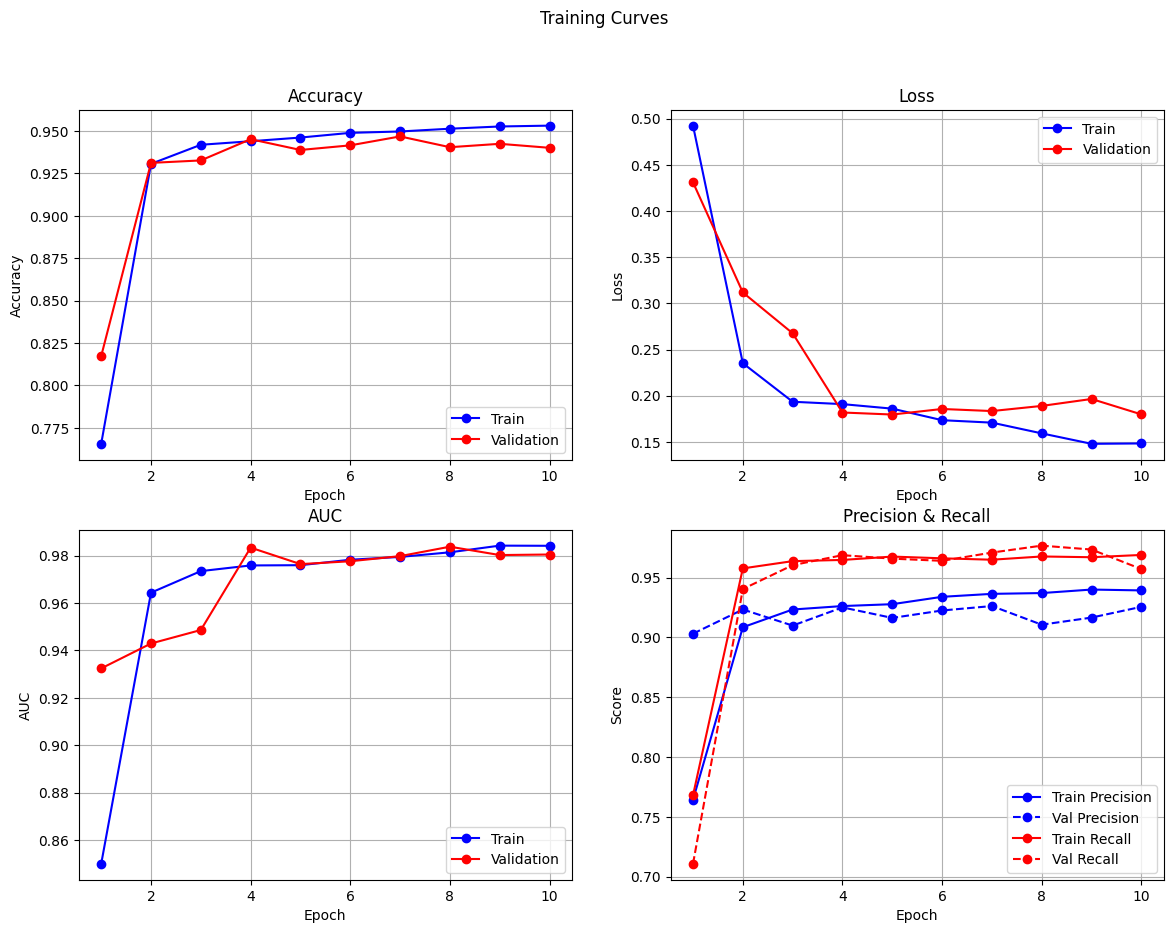

In [12]:
hist = history.history
epochs_range = range(1, len(hist['accuracy']) + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Accuracy
axes[0,0].plot(epochs_range, hist['accuracy'],     'b-o', label='Train')
axes[0,0].plot(epochs_range, hist['val_accuracy'], 'r-o', label='Validation')
axes[0,0].set_title('Accuracy')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend(); axes[0,0].grid(True)
# Loss
axes[0,1].plot(epochs_range, hist['loss'],     'b-o', label='Train')
axes[0,1].plot(epochs_range, hist['val_loss'], 'r-o', label='Validation')
axes[0,1].set_title('Loss')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(True)
# AUC
axes[1,0].plot(epochs_range, hist['auc'],     'b-o', label='Train')
axes[1,0].plot(epochs_range, hist['val_auc'], 'r-o', label='Validation')
axes[1,0].set_title('AUC')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('AUC')
axes[1,0].legend(); axes[1,0].grid(True)
# Precision & Recall together
axes[1,1].plot(epochs_range, hist['precision'],     'b-o', label='Train Precision')
axes[1,1].plot(epochs_range, hist['val_precision'], 'b--o', label='Val Precision')
axes[1,1].plot(epochs_range, hist['recall'],        'r-o', label='Train Recall')
axes[1,1].plot(epochs_range, hist['val_recall'],    'r--o', label='Val Recall')
axes[1,1].set_title('Precision & Recall')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Score')
axes[1,1].legend(); axes[1,1].grid(True)
plt.suptitle('Training Curves')
plt.show()


## 10. Evaluate on Validation Set


In [13]:
results = model.evaluate(val_gen, steps=len(val_gen), verbose=0)
metric_names = model.metrics_names

# unpack all 5 metrics
val_loss      = results[0]
val_acc       = results[1]
val_auc       = results[2]
val_precision = results[3]
val_recall    = results[4]
# tiny epsilon avoids a divide-by-zero if precision/recall ever becomes 0
val_f1        = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-8)

print("=" * 40)
print("       Validation Set Results")
print("=" * 40)
print(f"  Loss      : {val_loss:.4f}")
print(f"  Accuracy  : {val_acc:.4f}  ({val_acc*100:.2f}%)")
print(f"  AUC       : {val_auc:.4f}")
print(f"  Precision : {val_precision:.4f}")
print(f"  Recall    : {val_recall:.4f}")
print(f"  F1-Score  : {val_f1:.4f}")
print("=" * 40)


       Validation Set Results
  Loss      : 0.1796
  Accuracy  : 0.9388  (93.88%)
  AUC       : 0.9764
  Precision : 0.9163
  Recall    : 0.9659
  F1-Score  : 0.9404


## 11a. Confusion Matrix


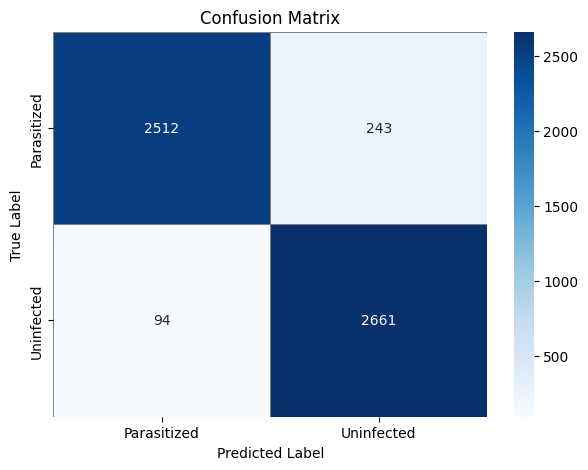

True Positives (correctly identified infected) : 2661
True Negatives (correctly identified healthy)  : 2512
False Positives (healthy flagged as infected)  : 243
False Negatives (infected missed by model)     : 94


In [14]:
# reset matters because validation generator was already used above
val_gen.reset()
y_pred_probs = model.predict(val_gen, steps=len(val_gen), verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (correctly identified infected) : {tp}")
print(f"True Negatives (correctly identified healthy)  : {tn}")
print(f"False Positives (healthy flagged as infected)  : {fp}")
print(f"False Negatives (infected missed by model)     : {fn}")


## 11b. Classification Report


In [15]:
# this gives precision/recall/f1 per class, not just one overall number
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

 Parasitized       0.96      0.91      0.94      2755
  Uninfected       0.92      0.97      0.94      2755

    accuracy                           0.94      5510
   macro avg       0.94      0.94      0.94      5510
weighted avg       0.94      0.94      0.94      5510



## 11c. ROC Curve


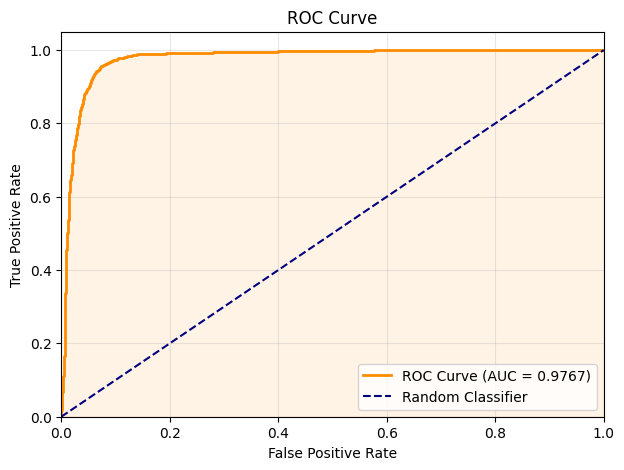

In [16]:
# ROC checks performance across thresholds, not only the 0.5 cut-off
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()
# higher AUC means the model ranks infected/healthy cells more cleanly


## 12. Model Interpretability ? Grad-CAM++

Grad-CAM shows which regions of a cell image the model is actually focusing on.
This is important for medical AI ? doctors need to verify the model is looking at
the right features (the parasite ring structure) and not some image artifact.


In [17]:
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore
import matplotlib.cm as mpl_cm

# use the last conv layer for grad-cam ? it has the most semantic info
# custom modifier avoids a Sequential/output_names issue in some Keras versions
def model_modifier(model):
    model.layers[-1].activation = tf.keras.activations.linear
    return model

gradcam = GradcamPlusPlus(model, model_modifier=model_modifier, clone=True)

# grab a small batch from val set
val_gen.reset()
sample_imgs, sample_labels = next(val_gen)
sample_imgs  = sample_imgs[:8]
sample_labels = sample_labels[:8]
preds = model.predict(sample_imgs, verbose=0).flatten()
pred_labels = (preds > 0.5).astype(int)

score = BinaryScore([int(p) for p in pred_labels])
cam = gradcam(score, sample_imgs)


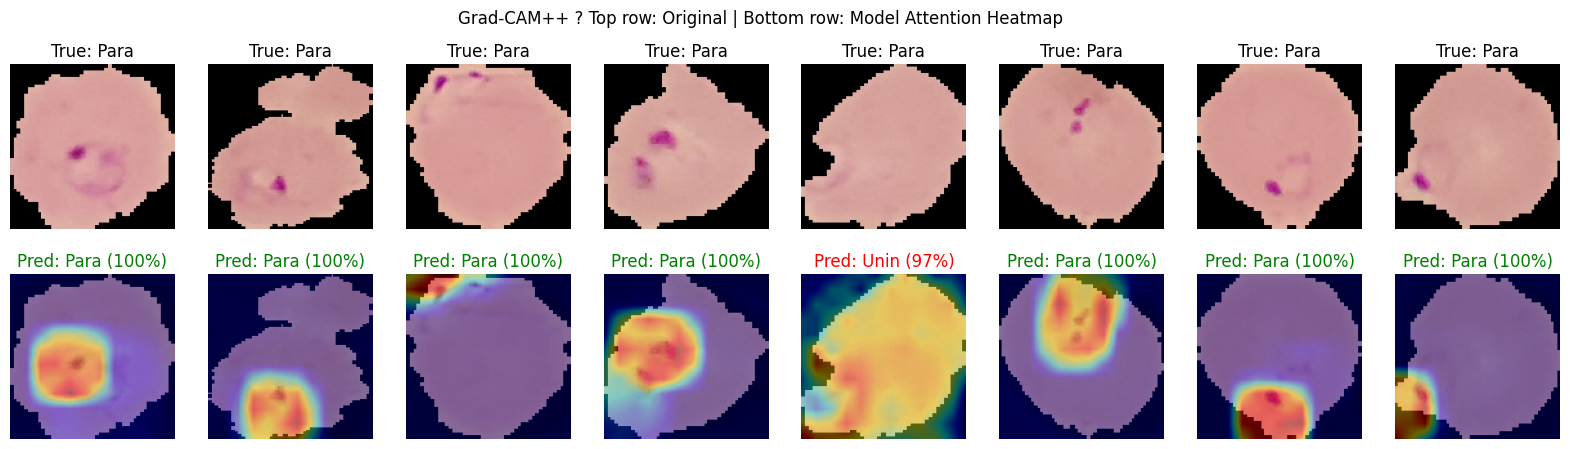

In [18]:
# plot 8 images: original + Grad-CAM overlay
fig, axes = plt.subplots(2, 8, figsize=(20, 5))

for i in range(8):
    orig = sample_imgs[i]
    heatmap = cam[i]
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    heatmap_color = cv2.resize(heatmap_color, IMG_SIZE)
    overlay = cv2.addWeighted((orig * 255).astype(np.uint8), 0.6,
                              heatmap_color, 0.4, 0)

    # comparing true vs predicted labels right on the heatmap
    true_lbl  = class_names[int(sample_labels[i])]
    pred_lbl  = class_names[pred_labels[i]]
    conf      = preds[i] if pred_labels[i] == 1 else 1 - preds[i]
    color     = 'green' if true_lbl == pred_lbl else 'red'

    axes[0, i].imshow(orig)
    axes[0, i].set_title(f"True: {true_lbl[:4]}")
    axes[0, i].axis('off')

    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f"Pred: {pred_lbl[:4]} ({conf:.0%})", color=color)
    axes[1, i].axis('off')

plt.suptitle('Grad-CAM++ ? Top row: Original | Bottom row: Model Attention Heatmap')
plt.show()
# this is the visual proof part for the report


## 13. Results Summary


In [19]:
# final table so the important numbers are all in one place
print("=" * 50)
print("         FINAL MODEL         ")
print("=" * 50)
print(f"  {'Metric':<20} {'Score':>10}")
print("-" * 50)
print(f"  {'Accuracy':<20} {val_acc*100:>9.2f}%")
print(f"  {'AUC':<20} {val_auc:>10.4f}")
print(f"  {'Precision':<20} {val_precision:>10.4f}")
print(f"  {'Recall':<20} {val_recall:>10.4f}")
print(f"  {'F1-Score':<20} {val_f1:>10.4f}")
print(f"  {'Val Loss':<20} {val_loss:>10.4f}")
print("=" * 50)
print(f"\n  Epochs trained     : {len(history.history['loss'])}")
print(f"  Early stopping     : patience=5")
print(f"  Augmentation       : rotation, flip, zoom, shift")
print(f"  Class weights used : {class_weights_dict}")
print(f"  Saved files        : best_model.h5, training_curves.png,")
print(f"                       confusion_matrix.png, roc_curve.png, gradcam_output.png")


         FINAL MODEL         
  Metric                    Score
--------------------------------------------------
  Accuracy                 93.88%
  AUC                      0.9764
  Precision                0.9163
  Recall                   0.9659
  F1-Score                 0.9404
  Val Loss                 0.1796

  Epochs trained     : 10
  Early stopping     : patience=5
  Augmentation       : rotation, flip, zoom, shift
  Class weights used : {0: 1.0, 1: 1.0}
  Saved files        : best_model.h5, training_curves.png,
                       confusion_matrix.png, roc_curve.png, gradcam_output.png


In [20]:
import winsound

for _ in range(5):
    winsound.Beep(800, 200)